# Decision Trees

Vamos a utilizar un arbol de decision para clasificar la seleccion entre dos farmacos para una serie de pacientes en base a distintas caracteristicas personales.

### SETUP

In [3]:
!pip install -q numpy==2.2.0
!pip install -q pandas==2.2.3
!pip install -q scikit-learn==1.6.0
!pip install -q matplotlib==3.9.3


import numpy as np 
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import metrics

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

### Dataset

Descarguemos el dataset y veamos un poco su esquema, vamos a notar que tenemos informacion de un grupo de pacientes que padecieron una enfermedad y tomaron uno de 5 distintos medicamentos (A/B/C/X/Y). Dentro de la informacion de los pacientes tenemos Edad, Sexo, Presion arterial y colesterol.



In [10]:
path= 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/drug200.csv'
my_data = pd.read_csv(path)
my_data.sample(3)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
137,35,F,HIGH,HIGH,12.894,drugA
116,67,M,NORMAL,NORMAL,9.514,drugX
94,56,M,LOW,HIGH,15.015,drugY


### Procesamiento y correlaciones

Podemos ver que contamos con 6 campos en nuestro dataset, de los cuales 4 no son numericos, esto nos imposibilita utilizarlos y por lo tanto tenemos que ignorarlos o pasarlos a valores numericos (en especial si queremos ver sus correlaciones con la variable objetivo), logicamente en este caso queremos aprovechar la maxima cantidad de features para las decisiones del arbol y por lo tanto utilizando Scikit obtenemos una transformacion de los valores.

In [11]:
label_encoder = LabelEncoder()

my_data['Sex'] = label_encoder.fit_transform(my_data['Sex'])    # F = 0, M = 1

my_data['BP'] = label_encoder.fit_transform(my_data['BP'])  # High = 0, Low = 1, Normal = 2

my_data['Cholesterol'] = label_encoder.fit_transform(my_data['Cholesterol'])    # High = 0, Normal = 1

custom_map = {'drugA':0,'drugB':1,'drugC':2,'drugX':3,'drugY':4}
my_data['Drug_num'] = my_data['Drug'].map(custom_map)

# Correlaciones
(my_data.drop('Drug', axis=1)).corr()


,Age,Sex,BP,Cholesterol,Na_to_K,Drug_num
Age,1.000000,0.102027,0.054212,-0.068234,-0.063119,-0.004828
Sex,0.102027,1.000000,-0.007814,-0.008811,-0.125008,-0.098573
BP,0.054212,-0.007814,1.000000,-0.137552,-0.149312,0.372868
Cholesterol,-0.068234,-0.008811,-0.137552,1.000000,0.010000,0.055629
Na_to_K,-0.063119,-0.125008,-0.149312,0.010000,1.000000,0.589120
Drug_num,-0.004828,-0.098573,0.372868,0.055629,0.589120,1.000000


Podemos ver que campos como la edad parecen tener poco efecto en la predicción de la droga a utilizar, pero en este contexto -y al utilizar arboles de decision- es conveniente dejarla para agregar una altura extra al arbol que permite subclasificar con mayor precisión la droga mas adecuada. 

## Modelado

Comencemos a modelar nuestro arbol de decisión, gracias a Scikit esto es bastante estandard y parecido a los modelos anteriores.

Vamos a agregar ademas una version sin la edad, para comparar su performance al remover una variable debilmente vinculada con la variable objetivo.

In [19]:
# Separamos variable objetivo de features
Y = my_data['Drug']

X = my_data.drop(['Drug', 'Drug_num'], axis=1)
X_V2 = X.drop(['Age'], axis=1)


# Formamos distintos datasets para entrenamiento y validacion
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size= 0.3, random_state=32)

X_V2_train, X_V2_test, Y_V2_train, Y_V2_test = train_test_split(X_V2,Y,test_size=0.3, random_state=32) 

# Armamos el modelo
tree = DecisionTreeClassifier(criterion="entropy", max_depth=4)
tree.fit(X_train,Y_train)

tree_v2 = DecisionTreeClassifier(criterion="entropy", max_depth=4)
tree_v2.fit(X_V2_train, Y_V2_train)


DecisionTreeClassifier(criterion='entropy', max_depth=4)

## Evaluacion y Visualizacion

Una vez armado el modelo, podemos analizar su correctitud y visualizar el arbol en si

First Trees's Accuracy:  0.9833333333333333
Second Trees's Accuracy:  0.9


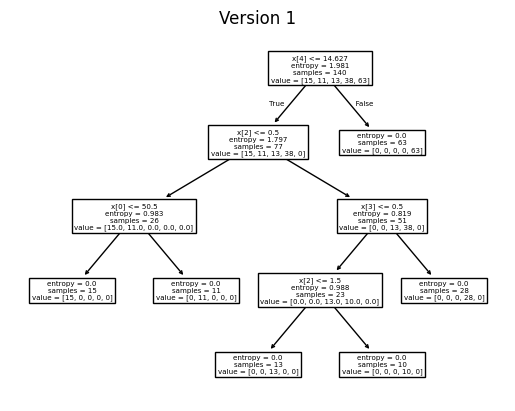

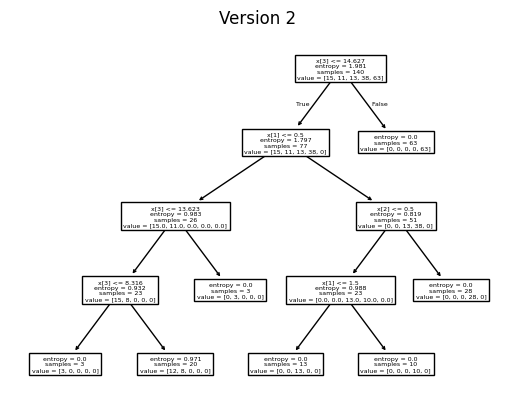

In [20]:
# Predicciones
tree_predictions = tree.predict(X_test)
tree_predictions_v2 = tree_v2.predict(X_V2_test)

# Metricas
print("First Trees's Accuracy: ", metrics.accuracy_score(Y_test, tree_predictions))
print("Second Trees's Accuracy: ", metrics.accuracy_score(Y_V2_test, tree_predictions_v2))

# Figuras
plot_tree(tree)
plt.title("Version 1")
plt.show()

plot_tree(tree_v2)
plt.title("Version 2")
plt.show()

## Conclusiones

Podemos observar que para nuestro primer modelo de arbol de decision tuvimos un fuerte exito en las predicciones (98% de aciertos), y que al sacar una feature débil nuestra capacidad de prediccion disminuyó.

Ciertamente hay que tener en cuenta que no toda variable puede estar relacionada con nuestro objetivo, podriamos tener features que arruinen la correctitud del modelo y/o produzcan un sesgo sobre las predicciones.